# 02 — Train Sparse Autoencoder

Train a Sparse Autoencoder on GPT-2 layer 6 residual stream activations.

The SAE learns an **overcomplete**, **sparse** decomposition of the activation space:
- **Overcomplete**: 6144 features for 768 dimensions (8x expansion)
- **Sparse**: L1 penalty ensures only ~20-50 features active per input

This is analogous to dictionary learning / sparse coding — but applied to neural
network activations to find interpretable computational features.

**Connection to X-ray scattering SVD:** In time-resolved scattering, SVD gives us
orthogonal components (temporal modes × structural modes). Here, we go beyond
orthogonality — the true "features" of neural computation are sparse and non-orthogonal,
so we need a method that can find them: the Sparse Autoencoder.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

from sae.model import SparseAutoencoder
from sae.activations import load_activations

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Load activations

In [2]:
activations = load_activations("../results/activations_layer6_2M.pt")
print(f"Activations shape: {activations.shape}")
print(f"d_model: {activations.shape[1]}")

Activations shape: torch.Size([2000000, 768])
d_model: 768


## SAE Configuration

In [3]:
# Hyperparameters
D_MODEL = activations.shape[1]  # 768
D_SAE = D_MODEL * 8             # 6144 (overcomplete)
L1_COEFF = 5e-3                 # Sparsity penalty
LR = 1e-3                       # Learning rate
BATCH_SIZE = 4096               # Large batch for stable training
N_STEPS = 15_000                # Training steps
WARMUP_STEPS = 500              # LR warmup

print(f"SAE architecture: {D_MODEL} → {D_SAE} → {D_MODEL}")
print(f"Expansion factor: {D_SAE / D_MODEL}x")
print(f"Samples available: {activations.shape[0]:,}")
print(f"Epochs: ~{N_STEPS * BATCH_SIZE / activations.shape[0]:.1f}")

SAE architecture: 768 → 6144 → 768
Expansion factor: 8.0x
Samples available: 2,000,000
Epochs: ~30.7


## Initialize and Train

In [4]:
# Initialize SAE
sae = SparseAutoencoder(d_model=D_MODEL, d_sae=D_SAE, l1_coeff=L1_COEFF).to(device)

# Optimizer with warmup + cosine decay
optimizer = torch.optim.Adam(sae.parameters(), lr=LR, betas=(0.9, 0.999))

def lr_schedule(step):
    if step < WARMUP_STEPS:
        return step / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / (N_STEPS - WARMUP_STEPS)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_schedule)

# Data loader
dataset = TensorDataset(activations)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"SAE parameters: {sum(p.numel() for p in sae.parameters()):,}")

SAE parameters: 9,444,096


In [5]:
# Training loop
history = {"loss": [], "mse_loss": [], "l1_loss": [], "l0": [], "lr": []}

sae.train()
step = 0
pbar = tqdm(total=N_STEPS, desc="Training")

while step < N_STEPS:
    for (batch,) in dataloader:
        if step >= N_STEPS:
            break

        batch = batch.to(device)
        
        # Forward pass
        output = sae(batch)
        
        # Backward pass
        optimizer.zero_grad()
        output["loss"].backward()
        optimizer.step()
        scheduler.step()
        
        # Normalize decoder weights (important: keeps L1 penalty meaningful)
        sae.normalize_decoder()
        
        # Log
        if step % 100 == 0:
            history["loss"].append(output["loss"].item())
            history["mse_loss"].append(output["mse_loss"].item())
            history["l1_loss"].append(output["l1_loss"].item())
            history["l0"].append(output["l0"].item())
            history["lr"].append(scheduler.get_last_lr()[0])
        
        if step % 1000 == 0:
            pbar.set_postfix({
                "loss": f"{output['loss'].item():.4f}",
                "MSE": f"{output['mse_loss'].item():.4f}",
                "L0": f"{output['l0'].item():.0f}",
            })
        
        step += 1
        pbar.update(1)

pbar.close()
print(f"\nFinal — Loss: {history['loss'][-1]:.4f}, MSE: {history['mse_loss'][-1]:.4f}, L0: {history['l0'][-1]:.0f}")

Training: 100%|█████████████████████████████████████████████████████████████████████| 15000/15000 [10:53<00:00, 22.95it/s, loss=0.0051, MSE=0.0010, L0=3774]


Final — Loss: 0.0051, MSE: 0.0010, L0: 3771


## Training Curves

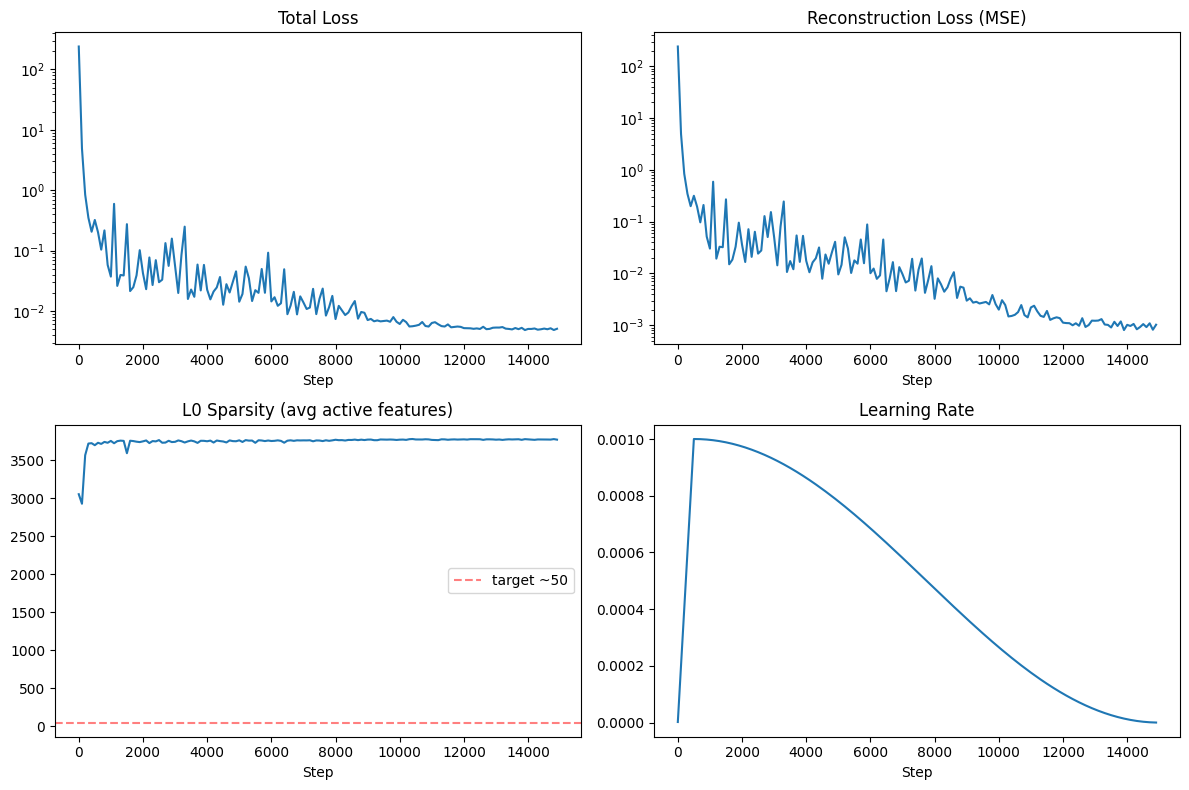

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

steps = np.arange(len(history["loss"])) * 100

axes[0, 0].plot(steps, history["loss"])
axes[0, 0].set_title("Total Loss")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_yscale("log")

axes[0, 1].plot(steps, history["mse_loss"])
axes[0, 1].set_title("Reconstruction Loss (MSE)")
axes[0, 1].set_xlabel("Step")
axes[0, 1].set_yscale("log")

axes[1, 0].plot(steps, history["l0"])
axes[1, 0].set_title("L0 Sparsity (avg active features)")
axes[1, 0].set_xlabel("Step")
axes[1, 0].axhline(y=50, color='r', linestyle='--', alpha=0.5, label='target ~50')
axes[1, 0].legend()

axes[1, 1].plot(steps, history["lr"])
axes[1, 1].set_title("Learning Rate")
axes[1, 1].set_xlabel("Step")

plt.tight_layout()
plt.savefig("../results/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Save trained model

In [7]:
# Save model
save_dict = {
    "model_state_dict": sae.state_dict(),
    "config": {
        "d_model": D_MODEL,
        "d_sae": D_SAE,
        "l1_coeff": L1_COEFF,
        "layer": 6,
        "model_name": "gpt2-small",
    },
    "training": {
        "n_steps": N_STEPS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "final_loss": history["loss"][-1],
        "final_mse": history["mse_loss"][-1],
        "final_l0": history["l0"][-1],
    },
    "history": history,
}
torch.save(save_dict, "../results/sae_gpt2small_layer6.pt")
print("Saved trained SAE to ../results/sae_gpt2small_layer6.pt")

Saved trained SAE to ../results/sae_gpt2small_layer6.pt


## Quick dead feature check

In [8]:
# Check for dead features on a sample
sae.eval()
with torch.no_grad():
    sample = activations[:10000].to(device)
    features = sae.encode(sample)
    dead = (features.max(dim=0).values == 0).sum().item()
    alive = D_SAE - dead

print(f"Alive features: {alive}/{D_SAE} ({100*alive/D_SAE:.1f}%)")
print(f"Dead features: {dead}/{D_SAE} ({100*dead/D_SAE:.1f}%)")

Alive features: 4552/6144 (74.1%)
Dead features: 1592/6144 (25.9%)


---
**Next:** `03_interpret_features.ipynb` — Analyze features and compare SVD vs SAE